In [ ]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import sys
from scipy.optimize import minimize, LinearConstraint

from polModel import get_p_bb

#sys.path.append("Gas_and_dust/fullspec_dust_models/")
sys.path.append("Gas_and_dust/")
from polWaveDust import PolWaveDust
from polWaveGas import PolWaveGas

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

In [2]:
#Object ID
wid = "W0116-0505"

In [3]:
#Load the properties of the BHDs
op = ObjectProperties(wids=[wid])

In [4]:
#Load the bands.
bands = ReadBands()

In [7]:
#Load the spectra for each BHD, extended using the best-fit SED.
specs = ReadExtrapolatedSpectra()

# #Put the W0116 spectrum in Synphot format. 
# full_spec = SourceSpectrum(Empirical1D, points=specs.lam_obs[wid], lookup_table=specs.flam[wid], keep_neg=True)

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


In [5]:
def chi2(x, p_bb_interp, bands, op):
    if x[0]<0 or x[0]>90. or x[1]<0. or x[1]>90.:
        return np.inf

    chi2_val = 0
    for bname in bands.bp:
        p_bb = p_bb_interp[bname](([x[0]], [x[1]]))*100
        chi2_val += ((p_bb-op.pfrac[wid][bname])/op.epfrac[wid][bname])**2

    return chi2_val
    

In [8]:
dust_types = ["Gas","SMC","LMC","MW"]

fws = [True, False, True]
bws = [False, True, True]
stypes = []
for i in range(len(fws)):
    stype = ""
    if fws[i]:
        stype += "FW"
    if bws[i]:
        stype += "BW"
    stypes.append(stype)


xopt = dict()
p_bb_interp = dict()

for dust_type in dust_types:

    print(dust_type)
    xopt[dust_type] = dict()
    p_bb_interp[dust_type] = dict()

    for i,stype in enumerate(stypes):
        print(stype)

        p_bb_interp[dust_type][stype] = get_p_bb(dust_type,specs,bands,wid,fw=fws[i],bw=bws[i])

        #Set the linear constraints.
        x0 = np.array([45., 45.])
        G = np.identity(x0.shape[0])
        min_vals = [0.,0.]
        max_vals = [90., 90.]
        lincon = LinearConstraint(G, min_vals, max_vals)

        #Run the fit
        xopt[dust_type][stype] = minimize(chi2, x0=x0, constraints=lincon, args=(p_bb_interp[dust_type][stype], bands, op)) 
        print(xopt[dust_type][stype])
    print()       

Gas
FW
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 70.90332611913726
       x: [ 4.020e+01  5.907e+01]
     nit: 9
     jac: [ 5.436e-05 -4.101e-05]
    nfev: 28
    njev: 9
BW
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 70.90332611913726
       x: [ 4.020e+01  5.907e+01]
     nit: 9
     jac: [ 5.436e-05 -4.101e-05]
    nfev: 28
    njev: 9
FWBW
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 70.90332611914276
       x: [ 4.020e+01  5.907e+01]
     nit: 9
     jac: [ 5.627e-05 -4.292e-05]
    nfev: 28
    njev: 9

SMC
FW
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 924.9035448794207
       x: [ 5.915e+01  4.395e+01]
     nit: 10
     jac: [ 0.000e+00  3.815e-05]
    nfev: 33
    njev: 10
BW
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 816.9524513610432
       x: [ 4.888e+01  6.061e+01]
     nit

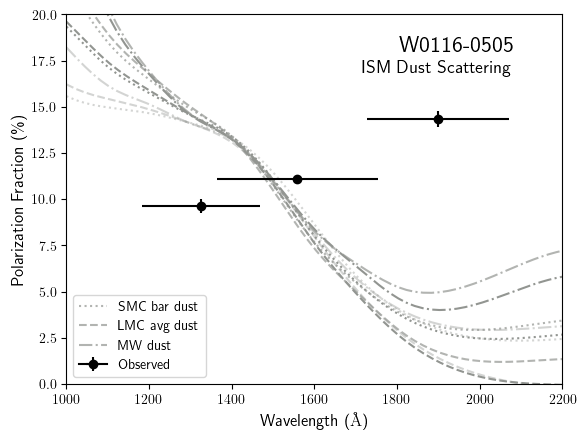

In [9]:
#Let's plot the best-fit models.

ltypes = {"Gas":"solid", "SMC":"dotted", "LMC":"dashed", "MW":"dashdot"}
alphas = {"FWBW": 1.0, "FW": 0.7, "BW": 0.4}

plot_labels = {"Gas":"Gas", "SMC":"SMC bar dust", "LMC":"LMC avg dust", "MW":"MW dust"}

fig, ax = plt.subplots(1)

for dust_type in dust_types:
    for i,stype in enumerate(stypes):

        th, psi = xopt[dust_type][stype].x

        if dust_type=="Gas":
            # model = PolWaveGas(fw=fws[i],bw=bws[i])
            # pmod = [100*model.p(([th],[psi]))]*len(specs.lam_rest[wid])
            continue
        else:
            model = PolWaveDust(dust_type, folder="Gas_and_dust/fullspec_dust_models/", fw=fws[i], bw=bws[i])
            pmod = 100*model.p((specs.lam_rest[wid].to(u.AA).value, th, psi))
        
        if i==0:
            label = plot_labels[dust_type]
        else:
            label = None
        ax.plot(specs.lam_rest[wid], pmod, linestyle=ltypes[dust_type], color='xkcd:gray', label=label, alpha=alphas[stype])

for j, bname in enumerate(op.pfrac[wid].keys()):
    if j==0:
        label = 'Observed'
    else:
        label = None
    ax.errorbar([bands.bp[bname].barlam().value/(1+op.z[wid])], [op.pfrac[wid][bname]], xerr=[bands.bp[bname].rectwidth().value/2./(1+op.z[wid])], yerr=[op.epfrac[wid][bname]], marker='o', color='k', label=label)

ax.legend(loc='lower left')
ax.text(0.9, 0.9, "W0116-0505", ha='right', transform=ax.transAxes, fontsize=16)
ax.text(0.9, 0.84, "ISM Dust Scattering", ha='right', transform=ax.transAxes, fontsize=13)
ax.set_xlim([1000,2200])
ax.set_ylim([0,20])
ax.set_ylabel("Polarization Fraction (\%)", fontsize=12)
ax.set_xlabel(r"Wavelength ($\rm \AA$)", fontsize=12)

fig.savefig("ISM_pol_W0116.png", dpi=100, bbox_inches='tight')